# Reconnaissance de Visages Masques avec ArcFace Loss
## Notebook Complet -- Kaggle P100

### Ameliorations appliquees
- Dataset normalise : dossiers p0001 a p0541 (nomenclature uniforme)
- `num_classes` derive automatiquement du pattern `p####`
- `class_to_idx` sauvegarde dans le checkpoint pour inference reproductible
- `train_epoch` et `validate_epoch` implementees
- CBAM insere apres forward_features(), avant GlobalAvgPool
- Scheduler reinitialise a chaque changement de phase
- numpy pinned to 1.26.4
- persistent_workers active pour les DataLoaders
- Augmentation renforcee : RandomResizedCrop, ColorJitter fort, RandomPerspective, GaussianBlur, RandomErasing (occlusion)

## 1. Installation des Dependances (Kaggle P100)

In [1]:
import subprocess, sys

print("=" * 70)
print("PYTORCH INSTALLER FOR KAGGLE P100 (SM 6.0)")
print("=" * 70)

subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "torch", "torchvision", "torchaudio"
], check=False)

print("\nInstalling torch==2.2.0+cu118")
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "torch==2.2.0+cu118", "torchvision==0.17.0+cu118", "torchaudio==2.2.0+cu118",
    "--index-url", "https://download.pytorch.org/whl/cu118", "-q"
], check=True)

print("\nPinning numpy==1.26.4")
subprocess.run([
    sys.executable, "-m", "pip", "install", "numpy==1.26.4", "-q"
], check=True)

print("\nInstalling timm, tqdm, scikit-learn")
subprocess.run([
    sys.executable, "-m", "pip", "install", "timm", "tqdm", "scikit-learn", "-q"
], check=True)

print("\nAll installations complete.")

PYTORCH INSTALLER FOR KAGGLE P100 (SM 6.0)
Found existing installation: torch 2.2.0+cu118
Uninstalling torch-2.2.0+cu118:
  Successfully uninstalled torch-2.2.0+cu118
Found existing installation: torchvision 0.17.0+cu118
Uninstalling torchvision-0.17.0+cu118:
  Successfully uninstalled torchvision-0.17.0+cu118
Found existing installation: torchaudio 2.2.0+cu118
Uninstalling torchaudio-2.2.0+cu118:
  Successfully uninstalled torchaudio-2.2.0+cu118

Installing torch==2.2.0+cu118

Pinning numpy==1.26.4

Installing timm, tqdm, scikit-learn

All installations complete.


## 1b. NumPy Sanity Check

In [2]:
import numpy as np
print(f"NumPy version: {np.__version__}")
assert np.__version__.startswith("1."), f"Expected numpy 1.x, got {np.__version__} -- restart kernel and re-run."
print("NumPy version OK.")

NumPy version: 1.26.4
NumPy version OK.


## 2. Import des Librairies

In [3]:
import os, gc, json, re
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
from torchvision import transforms
import timm
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available, t-SNE will be used instead")

from tqdm import tqdm
from pathlib import Path
from datetime import datetime
from collections import defaultdict

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("GPU INFORMATION")
print("=" * 70)
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA version   : {torch.version.cuda}")
else:
    print("No GPU -- CPU will be used (VERY SLOW)")
print("=" * 70)
print("All imports loaded!")

2026-05-21 13:01:20.643347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779368480.666380     461 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779368480.673953     461 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779368480.692290     461 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779368480.692307     461 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779368480.692309     461 computation_placer.cc:177] computation placer alr

GPU INFORMATION
CUDA Available : True
GPU            : Tesla P100-PCIE-16GB
VRAM           : 17.1 GB
CUDA version   : 11.8
All imports loaded!


## 3. Configuration

In [4]:
import os, torch, numpy as np

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_CUDA_DSA']       = '1'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class Config:
    # Dataset -- normalise p0001 a p0541
    USE_SUBSET         = False
    SUBSET_PERCENTAGE  = 0.2

    # Image
    image_size         = 224

    # Training
    batch_size         = 64
    num_epochs         = 40
    seed               = 42

    # Model
    embedding_dim      = 128
    model_name         = "efficientnet_b0"

    # ArcFace
    arcface_margin     = 0.3
    arcface_scale      = 64

    # Optimiser
    weight_decay       = 1e-4

    # Early stopping
    early_stopping_patience  = 5
    early_stopping_min_delta = 0.001

    # Kaggle output dir
    output_dir = '/kaggle/working'

    # num_classes sera defini en cellule 4 apres scan du dataset
    num_classes = None

torch.manual_seed(Config.seed)
np.random.seed(Config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.seed)

print("\nCONFIG -- KAGGLE P100")
print("=" * 70)
print(f"  Image size   : {Config.image_size}x{Config.image_size}")
print(f"  Batch size   : {Config.batch_size}")
print(f"  Epochs       : {Config.num_epochs}")
print(f"  Embedding dim: {Config.embedding_dim}")
print(f"  ArcFace      : margin={Config.arcface_margin}, scale={Config.arcface_scale}")
print(f"  Subset mode  : {Config.USE_SUBSET}")
print(f"  Output dir   : {Config.output_dir}")
print("=" * 70)

Device: cuda:0

CONFIG -- KAGGLE P100
  Image size   : 224x224
  Batch size   : 64
  Epochs       : 40
  Embedding dim: 128
  ArcFace      : margin=0.3, scale=64
  Subset mode  : False
  Output dir   : /kaggle/working


## 4. Chargement du Dataset Kaggle

Le dataset est normalise : tous les dossiers suivent le pattern `p####` (p0001 a p0541).
`num_classes` est derive automatiquement en comptant ces dossiers.
Le tri `sorted()` sur des noms uniformes garantit un ordre deterministe et reproductible.

In [5]:
# ─── Adapter ce chemin au nom exact de ton dataset Kaggle ───────────────────
# Visible dans : Kaggle > votre notebook > onglet "Data" (colonne de droite)
# Exemple affiché dans l'erreur : /kaggle/input/datasets/chaimaeelmounjali/maskeddataset
dataset_path = '/kaggle/input/datasets/chaimaeelmounjali/maskeddataset/Unified_Dataset'

print("Dataset Setup")
print("=" * 70)
print(f"Path: {dataset_path}")

# Pattern attendu : p suivi de 4 chiffres
_PERSON_RE = re.compile(r'^p\d{4}$')

if not os.path.exists(dataset_path):
    print(f"\n[ERREUR] Dossier introuvable : {dataset_path}")
    print("Chemins disponibles sous /kaggle/input/ :")
    for entry in sorted(os.listdir('/kaggle/input')):
        print(f"  /kaggle/input/{entry}")
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Lister uniquement les dossiers qui matchent p####
person_dirs = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
    and _PERSON_RE.match(d)
])

print(f"   Dossiers p#### trouvés : {len(person_dirs)}")

if len(person_dirs) == 0:
    print("\n[ERREUR] Aucun dossier p#### trouvé. Contenu du dataset_path :")
    for entry in sorted(os.listdir(dataset_path))[:20]:
        print(f"  {entry}")
    raise ValueError("Aucun dossier p#### trouvé. Vérifiez dataset_path et la structure du dataset.")

print(f"   Premier : {person_dirs[0]}  |  Dernier : {person_dirs[-1]}")

# Compter les images par sous-dossier
total_images   = 0
masked_count   = 0
unmasked_count = 0
for d in person_dirs:
    for sub in ['masked', 'non_masked']:
        sub_path = os.path.join(dataset_path, d, sub)
        if os.path.isdir(sub_path):
            n = len([f for f in os.listdir(sub_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            total_images += n
            if sub == 'masked':
                masked_count += n
            else:
                unmasked_count += n

print(f"   Images totales : {total_images}")
print(f"   Masquées       : {masked_count}")
print(f"   Non masquées   : {unmasked_count}")
print(f"   Avg/classe     : {total_images // len(person_dirs)}")

Config.num_classes = len(person_dirs)
print(f"\nConfig.num_classes = {Config.num_classes}  (p0001 à {person_dirs[-1]})")
print("=" * 70)

Dataset Setup
Path: /kaggle/input/datasets/chaimaeelmounjali/maskeddataset/Unified_Dataset
   Dossiers p#### trouvés : 541
   Premier : p0001  |  Dernier : p0541
   Images totales : 11097
   Masquées       : 5108
   Non masquées   : 5989
   Avg/classe     : 20

Config.num_classes = 541  (p0001 à p0541)


## 5. ArcFace Loss

In [6]:
class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss
    https://arxiv.org/abs/1801.07698
    """
    def __init__(self, num_classes, embedding_dim=128, margin=0.5, scale=64.0):
        super().__init__()
        self.num_classes   = num_classes
        self.embedding_dim = embedding_dim
        self.margin        = margin
        self.scale         = scale

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = np.cos(margin)
        self.sin_m = np.sin(margin)
        self.th    = np.cos(np.pi - margin)
        self.mm    = np.sin(np.pi - margin) * margin

        self.criterion = nn.CrossEntropyLoss()

    def forward(self, embeddings, labels):
        w = F.normalize(self.weight, p=2, dim=1)
        logits    = F.linear(embeddings, w)
        batch_idx = torch.arange(embeddings.size(0), device=embeddings.device)

        cos_theta   = logits[batch_idx, labels].unsqueeze(1)
        sin_theta   = torch.sqrt((1.0 - cos_theta.pow(2)).clamp(0, 1))
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        cos_theta_m = torch.where(cos_theta > self.th,
                                  cos_theta_m,
                                  cos_theta - self.mm)

        logits[batch_idx, labels] = cos_theta_m.squeeze(1)
        logits = logits * self.scale
        return self.criterion(logits, labels)

print("ArcFaceLoss defined.")

ArcFaceLoss defined.


## 6. CBAM -- Channel and Spatial Attention

EfficientNet-B0 contient deja des SE Blocks dans chaque MBConv.
Le CBAM est insere apres forward_features() et avant le GlobalAvgPool :
il raffine les canaux ET la localisation spatiale, utile pour ignorer
le masque et se concentrer sur les yeux, le front et les tempes.

In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
    def forward(self, x):
        avg_pool = x.mean(dim=[2, 3])
        max_pool = x.amax(dim=[2, 3])
        scale = torch.sigmoid(self.mlp(avg_pool) + self.mlp(max_pool))
        return x * scale.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg_map = x.mean(dim=1, keepdim=True)
        max_map = x.amax(dim=1, keepdim=True)
        scale = torch.sigmoid(self.conv(torch.cat([avg_map, max_map], dim=1)))
        return x * scale


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention()
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

print("CBAM defined.")

CBAM defined.


## 7. Architecture du Modele (EfficientNet-B0 + CBAM + Embedding)

In [8]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True)
        backbone_out  = self.backbone.num_features  # 1280
        self.backbone.reset_classifier(0)
        self.cbam = CBAM(channels=backbone_out, reduction=16)
        self.embedding_layer = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features   = self.backbone.forward_features(x)   # [B, 1280, H, W]
        features   = self.cbam(features)                 # channel + spatial attention
        if features.dim() > 2:
            features = features.mean(dim=[2, 3])         # global avg pool
        embeddings = self.embedding_layer(features)
        return F.normalize(embeddings, p=2, dim=1)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_blocks(self, n=2):
        if hasattr(self.backbone, 'blocks'):
            total = len(self.backbone.blocks)
            for i, block in enumerate(self.backbone.blocks):
                for p in block.parameters():
                    p.requires_grad = (i >= total - n)


model = FaceRecognitionModel(embedding_dim=Config.embedding_dim).to(device)

total       = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
cbam_params = sum(p.numel() for p in model.cbam.parameters())
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")
print(f"CBAM params      : {cbam_params:,}")
print("Model ready.")

Total params     : 4,376,670
Trainable params : 4,376,670
CBAM params      : 204,898
Model ready.


## 8. Transformations et Dataset

Le dataset etant normalise (p0001..p0541), `sorted()` produit un ordre
numerique correct et deterministe. Le filtre `_PERSON_RE` exclut tout
fichier parasite (mapping.json, .DS_Store, etc.) qui aurait pu trainer.

### Augmentation renforcee (anti-overfitting)
- `RandomResizedCrop` : recadrage aleatoire agressif (scale 0.5-1.0)
- `ColorJitter` : variations de luminosite/contraste/saturation/teinte plus fortes
- `RandomGrayscale` : simule eclairages atypiques (p=0.15)
- `RandomPerspective` : deformation legere pour la robustesse geometrique
- `RandomErasing` : occlusion aleatoire simulant des masques / obstructions
- `GaussianBlur` : flou aleatoire pour robustesse a la nettete

In [9]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# ---------------------------------------------------------------------------
# Augmentation renforcee -- reduit l'overfitting (train acc ~97% vs val ~65%)
#
#  1. RandomResizedCrop  : recadrage agressif (scale=0.5-1.0) force le modele
#                          a reconnaitre le visage depuis des vues partielles
#  2. ColorJitter fort   : simule conditions d'eclairage variees
#  3. RandomGrayscale    : simule cameras N&B ou mauvais eclairage
#  4. RandomPerspective  : legere deformation geometrique
#  5. GaussianBlur       : robustesse aux images floues / basse resolution
#  6. RandomErasing      : occlusion aleatoire (simule masques partiels,
#                          mains devant le visage, etc.)
# ---------------------------------------------------------------------------

train_transforms = transforms.Compose([
    # Redimensionnement + recadrage aleatoire agressif
    transforms.Resize((Config.image_size + 64, Config.image_size + 64)),
    transforms.RandomResizedCrop(
        Config.image_size,
        scale=(0.5, 1.0),   # recadre entre 50 % et 100 % de l'image
        ratio=(0.85, 1.15), # aspect ratio quasi-carre
    ),
    # Retournement et rotation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    # Photometrie plus agressive
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.1,
    ),
    transforms.RandomGrayscale(p=0.15),
    # Geometrie legere
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    # Flou
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    # Conversion en tenseur AVANT RandomErasing (qui travaille sur tensor)
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    # Occlusion aleatoire : simule masques, mains, objet devant le visage
    transforms.RandomErasing(
        p=0.5,
        scale=(0.02, 0.25),  # efface 2%-25% de la surface
        ratio=(0.3, 3.3),
        value='random',      # pixels remplaces par du bruit aleatoire
    ),
])

val_transforms = transforms.Compose([
    transforms.Resize((Config.image_size + 32, Config.image_size + 32)),
    transforms.CenterCrop(Config.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print("Augmentation renforcee activee :")
print("  - RandomResizedCrop (scale 0.5-1.0)")
print("  - ColorJitter fort (brightness/contrast 0.4, saturation 0.3, hue 0.1)")
print("  - RandomPerspective (distortion 0.2, p=0.3)")
print("  - GaussianBlur (sigma 0.1-1.5)")
print("  - RandomErasing (p=0.5, scale 2%-25%, valeur aleatoire)")

# Pattern p#### -- filtre tout ce qui n'est pas un dossier personne
_PERSON_RE = re.compile(r'^p\d{4}$')


class FaceDataset(Dataset):
    """
    Charge les images depuis root/p####/masked/*.jpg
    et root/p####/non_masked/*.jpg.

    Seuls les dossiers matchant le pattern p#### sont charges.
    Le tri est numeriquement stable car tous les noms ont le meme format.
    """

    def __init__(self, dataset_path, transform=None):
        self.dataset_path = Path(dataset_path)
        self.transform    = transform

        # Uniquement les dossiers p####, tries alphabetiquement (= numeriquement)
        self.classes = sorted([
            d for d in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, d))
            and _PERSON_RE.match(d)
        ])

        if not self.classes:
            raise ValueError(
                f"Aucun dossier p#### trouve dans {dataset_path}. "
                "Verifiez que le dataset a ete normalise."
            )

        # Mapping nom -> index (p0001->0, p0002->1, ...)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

        self.images, self.labels = [], []
        for cls_name in self.classes:
            cls_idx  = self.class_to_idx[cls_name]
            cls_path = self.dataset_path / cls_name
            for sub in ['masked', 'non_masked']:
                sub_path = cls_path / sub
                if sub_path.is_dir():
                    for f in sub_path.iterdir():
                        if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                            self.images.append(str(f))
                            self.labels.append(cls_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img   = Image.open(self.images[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            print(f"Error loading {self.images[idx]}: {e}")
            return self.__getitem__((idx + 1) % len(self))


print("Transforms and FaceDataset defined.")

Augmentation renforcee activee :
  - RandomResizedCrop (scale 0.5-1.0)
  - ColorJitter fort (brightness/contrast 0.4, saturation 0.3, hue 0.1)
  - RandomPerspective (distortion 0.2, p=0.3)
  - GaussianBlur (sigma 0.1-1.5)
  - RandomErasing (p=0.5, scale 2%-25%, valeur aleatoire)
Transforms and FaceDataset defined.


## 9. Creation des DataLoaders (80/20 split)

In [10]:
print("=" * 70)
print("DATASET PREPARATION")
print("=" * 70)

full_dataset = FaceDataset(dataset_path, transform=None)
print(f"Total images    : {len(full_dataset)}")
print(f"Classes (p####) : {len(full_dataset.classes)}")
print(f"Premier         : {full_dataset.classes[0]}  ->  index 0")
print(f"Dernier         : {full_dataset.classes[-1]}  ->  index {len(full_dataset.classes)-1}")

# Verifier la coherence avec Config
assert len(full_dataset.classes) == Config.num_classes, (
    f"Mismatch: FaceDataset a trouve {len(full_dataset.classes)} classes "
    f"mais Config.num_classes={Config.num_classes}"
)

# Subset optionnel
if Config.USE_SUBSET:
    n_sub   = max(1, int(len(full_dataset.classes) * Config.SUBSET_PERCENTAGE))
    sub_cls = set(full_dataset.classes[:n_sub])
    sub_imgs, sub_lbls = [], []
    for img, lbl in zip(full_dataset.images, full_dataset.labels):
        if full_dataset.classes[lbl] in sub_cls:
            sub_imgs.append(img)
            sub_lbls.append(lbl)
    old_idxs = sorted({full_dataset.class_to_idx[c] for c in sub_cls})
    remap    = {old: new for new, old in enumerate(old_idxs)}
    sub_lbls = [remap[l] for l in sub_lbls]

    class _SubFaceDataset(Dataset):
        def __init__(self, imgs, lbls, transform=None):
            self.images, self.labels, self.transform = imgs, lbls, transform
        def __len__(self):
            return len(self.images)
        def __getitem__(self, idx):
            try:
                img = Image.open(self.images[idx]).convert('RGB')
                if self.transform:
                    img = self.transform(img)
                return img, self.labels[idx]
            except Exception:
                return self.__getitem__((idx + 1) % len(self))

    base_ds            = _SubFaceDataset(sub_imgs, sub_lbls)
    Config.num_classes = n_sub
    print(f"SUBSET: {n_sub} classes, {len(sub_imgs)} images")
else:
    base_ds = full_dataset
    print(f"FULL DATASET: {Config.num_classes} classes, {len(base_ds)} images")

# Train / Val split 80/20
gen     = torch.Generator().manual_seed(Config.seed)
n_train = int(0.8 * len(base_ds))
n_val   = len(base_ds) - n_train
train_idx, val_idx = torch.utils.data.random_split(
    range(len(base_ds)), [n_train, n_val], generator=gen
)
train_idx, val_idx = list(train_idx), list(val_idx)
print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")


class _IndexedDataset(Dataset):
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, lbl = self.base[self.indices[i]]
        if self.transform and not isinstance(img, torch.Tensor):
            img = self.transform(img)
        return img, lbl


train_dataset = _IndexedDataset(base_ds, train_idx, train_transforms)
val_dataset   = _IndexedDataset(base_ds, val_idx,   val_transforms)

NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset, batch_size=Config.batch_size,
    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=Config.batch_size,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print("DataLoaders ready.")

DATASET PREPARATION
Total images    : 11097
Classes (p####) : 541
Premier         : p0001  ->  index 0
Dernier         : p0541  ->  index 540
FULL DATASET: 541 classes, 11097 images
Train: 8877 | Val: 2220
Train batches: 139 | Val batches: 35
DataLoaders ready.


## 10. Initialisation de l'Entrainement

In [11]:
criterion = ArcFaceLoss(
    num_classes   = Config.num_classes,
    embedding_dim = Config.embedding_dim,
    margin        = Config.arcface_margin,
    scale         = Config.arcface_scale,
).to(device)

def make_optimizer(lr):
    return AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=lr, weight_decay=Config.weight_decay,
    )

optimizer = make_optimizer(lr=0.001)

def make_scheduler(opt, t_max, eta_min=1e-5):
    return CosineAnnealingLR(opt, T_max=t_max, eta_min=eta_min)

scheduler = make_scheduler(optimizer, t_max=3)

history = {
    'train_loss': [], 'train_accuracy': [],
    'val_loss':   [], 'val_accuracy':   [],
    'learning_rate': []
}

best_val_accuracy      = 0.0
early_stopping_counter = 0
best_model_state       = None
optimal_threshold      = 0.5

print("Criterion, optimiser and scheduler created.")
print(f"   ArcFace margin={Config.arcface_margin}, scale={Config.arcface_scale}")
print(f"   Num classes={Config.num_classes}")

Criterion, optimiser and scheduler created.
   ArcFace margin=0.3, scale=64
   Num classes=541


## 11. Fonctions train_epoch et validate_epoch

In [12]:
def train_epoch(epoch):
    model.train()
    criterion.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Train Ep{epoch+1}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        embeddings = model(images)
        loss       = criterion(embeddings, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(criterion.parameters()), max_norm=1.0
        )
        optimizer.step()

        with torch.no_grad():
            w       = F.normalize(criterion.weight, p=2, dim=1)
            logits  = F.linear(embeddings, w) * Config.arcface_scale
            preds   = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        total_loss += loss.item() * labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def validate_epoch(epoch):
    model.eval()
    criterion.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_emb, all_lbl = [], []

    pbar = tqdm(val_loader, desc=f"Val   Ep{epoch+1}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        embeddings = model(images)
        loss       = criterion(embeddings, labels)

        w      = F.normalize(criterion.weight, p=2, dim=1)
        logits = F.linear(embeddings, w) * Config.arcface_scale
        preds  = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        all_emb.append(embeddings.cpu())
        all_lbl.append(labels.cpu())

    return total_loss / total, 100.0 * correct / total, torch.cat(all_emb), torch.cat(all_lbl)


print("train_epoch and validate_epoch defined.")

train_epoch and validate_epoch defined.


## 12. Validation GPU avant Entrainement

In [13]:
if not torch.cuda.is_available():
    raise RuntimeError("GPU (CUDA) is required. Enable it in Kaggle settings.")

cc        = torch.cuda.get_device_capability(0)
req_sm    = f"sm_{cc[0]}{cc[1]}"
arch_list = torch.cuda.get_arch_list() if hasattr(torch.cuda, "get_arch_list") else []
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"CC   : {cc[0]}.{cc[1]}  ({req_sm})")
if arch_list and req_sm not in arch_list:
    raise RuntimeError(f"No kernels for {req_sm}. Wheel supports {arch_list}.")

with torch.no_grad():
    _x = torch.randn(2, 3, Config.image_size, Config.image_size, device='cuda')
    _l = torch.tensor([0, 1], device='cuda')
    _e = model(_x)
    _s = criterion(_e, _l)
print(f"GPU smoke test passed. Loss={_s.item():.4f}")
del _x, _l, _e, _s
torch.cuda.empty_cache()

GPU  : Tesla P100-PCIE-16GB
CC   : 6.0  (sm_60)
GPU smoke test passed. Loss=40.4665


## 13. Entrainement en 3 Phases

Phase 1 (ep 1-3)  : backbone gele, CBAM + embedding_layer s'entrainent -- LR=1e-3
Phase 2 (ep 4-8)  : derniers 2 blocs EfficientNet degelent -- LR=1e-4
Phase 3 (ep 9+)   : modele entier -- LR=5e-5

In [14]:
print("=" * 70)
print("TRAINING -- 3 PHASES")
print("=" * 70)

current_phase = None

for epoch in range(Config.num_epochs):

    if epoch < 3:
        phase = 1
        if current_phase != 1:
            current_phase = 1
            model.freeze_backbone()
            for p in model.cbam.parameters():
                p.requires_grad = True
            for p in model.embedding_layer.parameters():
                p.requires_grad = True
            optimizer = make_optimizer(lr=1e-3)
            scheduler = make_scheduler(optimizer, t_max=3)
            print("\nPHASE 1 (Ep 1-3): Freeze backbone -- LR=1e-3")

    elif epoch < 8:
        phase = 2
        if current_phase != 2:
            current_phase = 2
            model.unfreeze_last_n_blocks(n=2)
            optimizer = make_optimizer(lr=1e-4)
            scheduler = make_scheduler(optimizer, t_max=5)
            print("\nPHASE 2 (Ep 4-8): Unfreeze last 2 blocks -- LR=1e-4")

    else:
        phase = 3
        if current_phase != 3:
            current_phase = 3
            model.unfreeze_backbone()
            optimizer = make_optimizer(lr=5e-5)
            scheduler = make_scheduler(
                optimizer, t_max=Config.num_epochs - 8, eta_min=1e-6
            )
            print("\nPHASE 3 (Ep 9+): Full model -- LR=5e-5")

    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{Config.num_epochs}  |  Phase {phase}")

    train_loss, train_acc               = train_epoch(epoch)
    val_loss, val_acc, val_emb, val_lbl = validate_epoch(epoch)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])

    print(f"  Train  loss={train_loss:.4f}  acc={train_acc:.2f}%")
    print(f"  Val    loss={val_loss:.4f}  acc={val_acc:.2f}%")
    print(f"  LR = {optimizer.param_groups[0]['lr']:.2e}")

    if val_acc >= best_val_accuracy + Config.early_stopping_min_delta:
        best_val_accuracy      = val_acc
        early_stopping_counter = 0
        best_model_state = {
            'model'       : {k: v.cpu() for k, v in model.state_dict().items()},
            'criterion'   : {k: v.cpu() for k, v in criterion.state_dict().items()},
            'epoch'       : epoch,
            'val_accuracy': val_acc,
            'val_emb'     : val_emb,
            'val_lbl'     : val_lbl,
        }
        print(f"  New best model! acc={val_acc:.2f}%")
    else:
        early_stopping_counter += 1
        print(f"  No improvement ({early_stopping_counter}/{Config.early_stopping_patience})")
        if early_stopping_counter >= Config.early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print(f"   Best val accuracy : {best_val_accuracy:.2f}%")
print(f"   Epochs completed  : {epoch+1}/{Config.num_epochs}")
print("=" * 70)

TRAINING -- 3 PHASES

PHASE 1 (Ep 1-3): Freeze backbone -- LR=1e-3

Epoch 1/40  |  Phase 1


  Train  loss=30.9732  acc=1.13%
  Val    loss=27.2203  acc=1.62%
  LR = 7.53e-04
  New best model! acc=1.62%

Epoch 2/40  |  Phase 1


  Train  loss=26.0450  acc=3.18%
  Val    loss=25.6891  acc=3.38%
  LR = 2.58e-04
  New best model! acc=3.38%

Epoch 3/40  |  Phase 1


  Train  loss=24.9728  acc=5.02%
  Val    loss=25.0866  acc=4.28%
  LR = 1.00e-05
  New best model! acc=4.28%

PHASE 2 (Ep 4-8): Unfreeze last 2 blocks -- LR=1e-4

Epoch 4/40  |  Phase 2


  Train  loss=24.2995  acc=7.87%
  Val    loss=24.3581  acc=8.24%
  LR = 9.14e-05
  New best model! acc=8.24%

Epoch 5/40  |  Phase 2


...

  Train  loss=14.1398  acc=76.67%
  Val    loss=18.1954  acc=55.05%
  LR = 2.86e-06
  New best model! acc=55.05%

Epoch 37/40  |  Phase 3


  Train  loss=14.0744  acc=76.34%
  Val    loss=18.1500  acc=55.23%
  LR = 2.05e-06
  New best model! acc=55.23%

Epoch 38/40  |  Phase 3


  Train  loss=14.0408  acc=75.88%
  Val    loss=18.1053  acc=55.27%
  LR = 1.47e-06
  New best model! acc=55.27%

Epoch 39/40  |  Phase 3


  Train  loss=14.0886  acc=75.69%
  Val    loss=18.1045  acc=55.23%
  LR = 1.12e-06
  No improvement (1/5)

Epoch 40/40  |  Phase 3


  Train  loss=14.0807  acc=75.94%
  Val    loss=18.0666  acc=55.77%
  LR = 1.00e-06
  New best model! acc=55.77%

TRAINING COMPLETE
   Best val accuracy : 55.77%
   Epochs completed  : 40/40


## 14. Chargement du Meilleur Modele et Evaluation

In [15]:
if best_model_state is None:
    raise RuntimeError("No model was saved -- check training loop.")

model.load_state_dict(best_model_state['model'])
criterion.load_state_dict(best_model_state['criterion'])

best_epoch    = best_model_state['epoch']
best_accuracy = best_model_state['val_accuracy']
emb_np        = best_model_state['val_emb'].numpy()
lbl_np        = best_model_state['val_lbl'].numpy()

print(f"Best model loaded  (epoch {best_epoch+1}, val acc={best_accuracy:.2f}%)")

w_np      = F.normalize(criterion.weight, p=2, dim=1).detach().cpu().numpy()
logits_np = emb_np @ w_np.T * Config.arcface_scale
pred_lbl  = logits_np.argmax(axis=1)

n         = len(emb_np)
max_pairs = min(20_000, n * (n - 1) // 2)
rng       = np.random.default_rng(Config.seed)

pair_scores, pair_labels = [], []
for i in rng.choice(n, size=min(n, 300), replace=False):
    for j in range(i + 1, n):
        if len(pair_scores) >= max_pairs:
            break
        sim = float(np.dot(emb_np[i], emb_np[j]) /
                    (np.linalg.norm(emb_np[i]) * np.linalg.norm(emb_np[j]) + 1e-8))
        pair_scores.append(sim)
        pair_labels.append(1 if lbl_np[i] == lbl_np[j] else 0)
    if len(pair_scores) >= max_pairs:
        break

pair_scores = np.array(pair_scores)
pair_labels = np.array(pair_labels)

fpr, tpr, thresholds = roc_curve(pair_labels, pair_scores)
auc_score = auc(fpr, tpr)

far_arr  = fpr
frr_arr  = 1 - tpr
opt_idx  = np.argmin(far_arr + frr_arr)
optimal_threshold = float(thresholds[opt_idx])
false_accepts     = float(far_arr[opt_idx])
false_rejects     = float(frr_arr[opt_idx])

print("\nEVALUATION METRICS")
print("=" * 70)
print(f"  Accuracy         : {best_accuracy:.2f}%")
print(f"  AUC              : {auc_score:.4f}")
print(f"  Optimal threshold: {optimal_threshold:.4f}")
print(f"  FAR @ threshold  : {false_accepts*100:.2f}%")
print(f"  FRR @ threshold  : {false_rejects*100:.2f}%")
print("=" * 70)

Best model loaded  (epoch 40, val acc=55.77%)

EVALUATION METRICS
  Accuracy         : 55.77%
  AUC              : 0.8872
  Optimal threshold: 0.2111
  FAR @ threshold  : 11.19%
  FRR @ threshold  : 18.18%


## 15. Visualisations

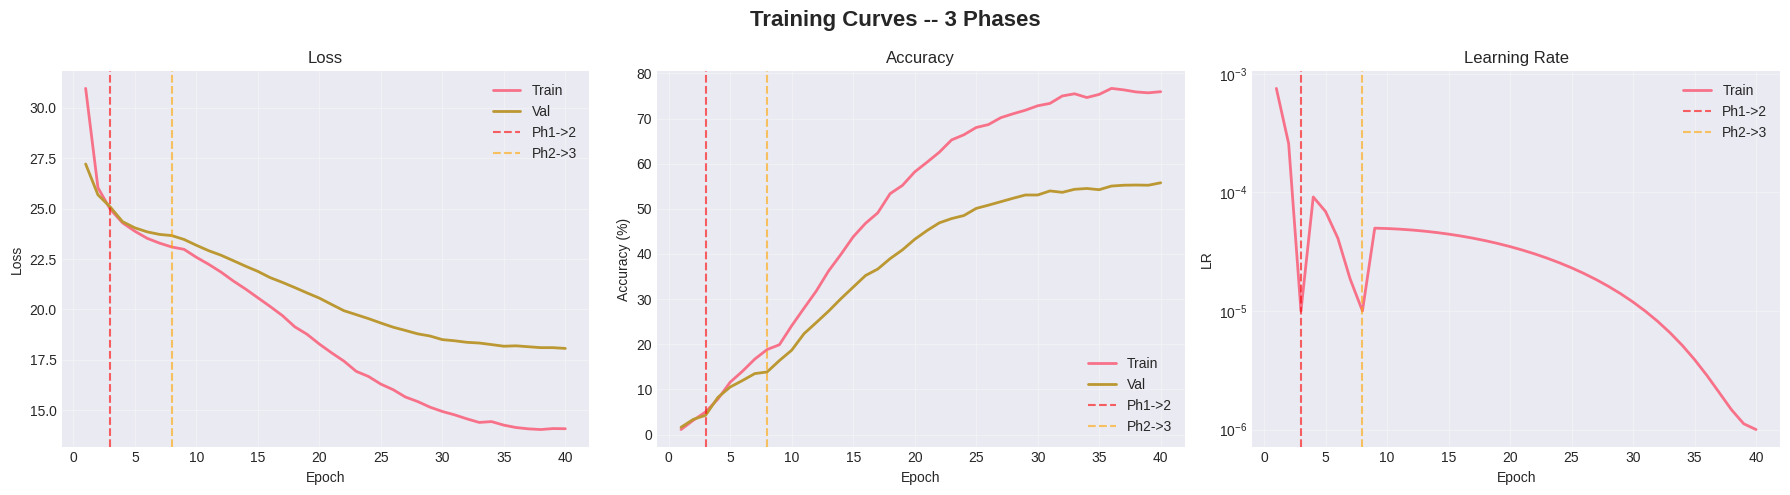

training_curves.png saved


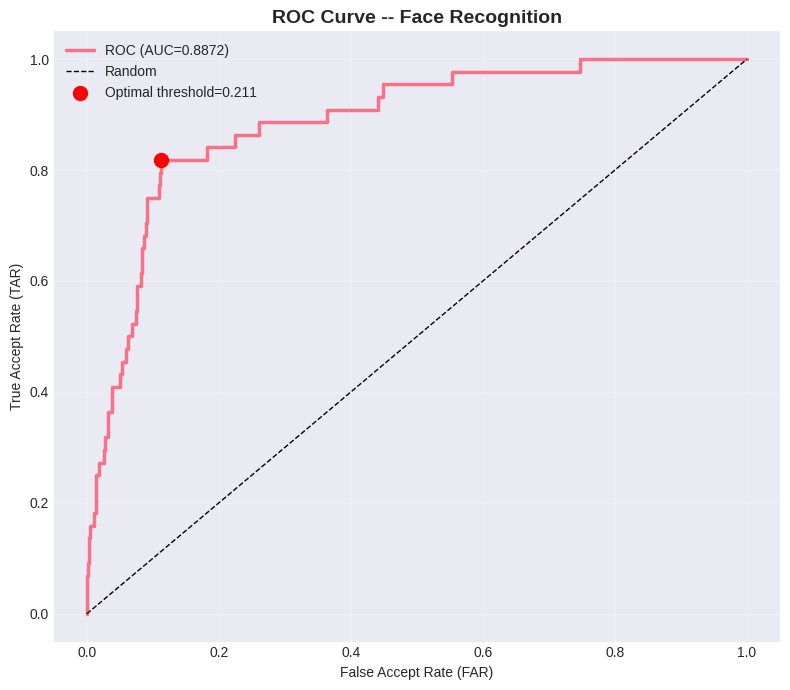

roc_curve.png saved

Computing t-SNE (may take a few minutes)...


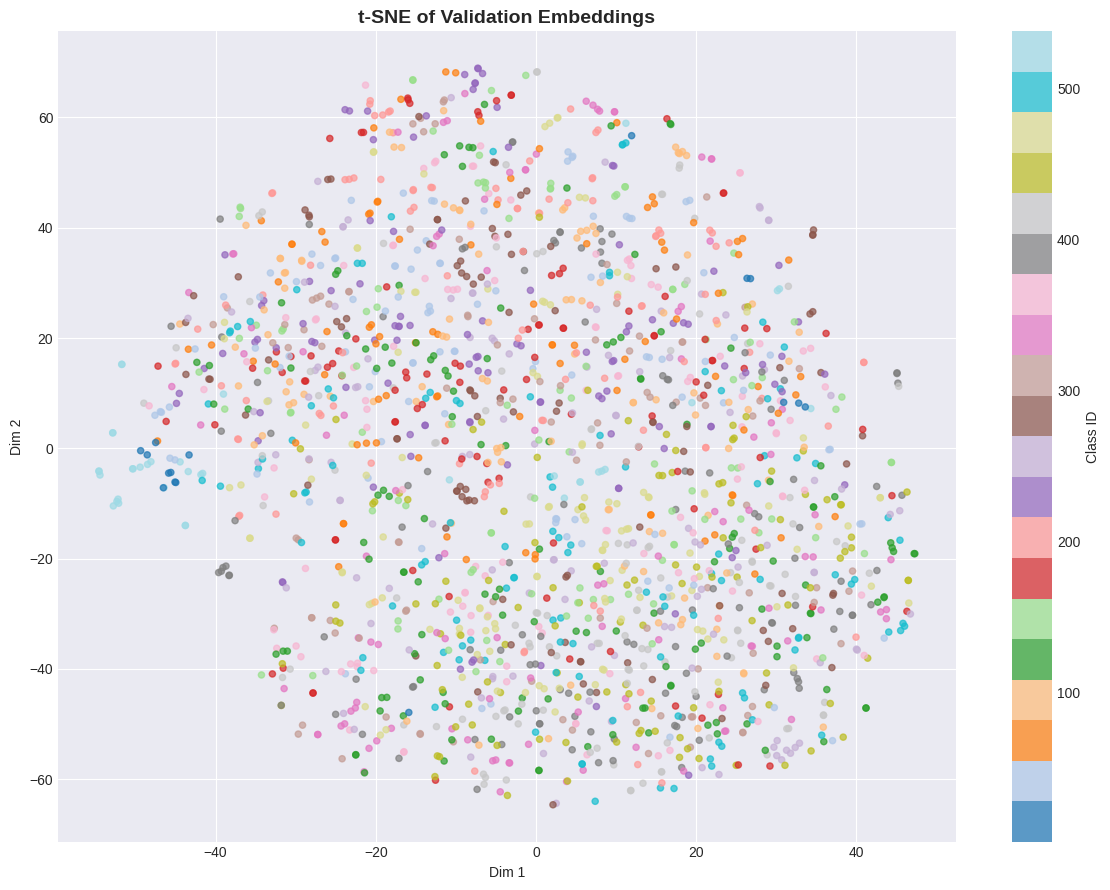

tsne_embeddings.png saved


In [16]:
out = Config.output_dir
os.makedirs(out, exist_ok=True)

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves -- 3 Phases', fontsize=16, fontweight='bold')
epochs_done = range(1, len(history['train_loss']) + 1)

for ax, (tr, va, title, ylabel) in zip(axes, [
    (history['train_loss'],     history['val_loss'],     'Loss',          'Loss'),
    (history['train_accuracy'], history['val_accuracy'], 'Accuracy',      'Accuracy (%)'),
    (history['learning_rate'],  None,                    'Learning Rate', 'LR'),
]):
    ax.plot(epochs_done, tr, label='Train', linewidth=2)
    if va is not None:
        ax.plot(epochs_done, va, label='Val', linewidth=2)
    for xv, col, lbl in [(3, 'red', 'Ph1->2'), (8, 'orange', 'Ph2->3')]:
        if xv < len(history['train_loss']):
            ax.axvline(x=xv, color=col, linestyle='--', alpha=0.6, label=lbl)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if ylabel == 'LR':
        ax.set_yscale('log')

plt.tight_layout()
plt.savefig(f'{out}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("training_curves.png saved")

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC={auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.scatter(false_accepts, 1 - false_rejects, color='red', s=100, zorder=5,
           label=f'Optimal threshold={optimal_threshold:.3f}')
ax.set_xlabel('False Accept Rate (FAR)')
ax.set_ylabel('True Accept Rate (TAR)')
ax.set_title('ROC Curve -- Face Recognition', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{out}/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("roc_curve.png saved")

# Confusion matrix (<=20 classes)
if Config.num_classes <= 20:
    cm = confusion_matrix(lbl_np, pred_lbl)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out}/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("confusion_matrix.png saved")

# t-SNE
print("\nComputing t-SNE (may take a few minutes)...")
max_tsne = min(2000, len(emb_np))
idx_tsne = np.random.choice(len(emb_np), max_tsne, replace=False)
tsne     = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_2d   = tsne.fit_transform(emb_np[idx_tsne])

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=lbl_np[idx_tsne], cmap='tab20', s=20, alpha=0.7)
ax.set_title('t-SNE of Validation Embeddings', fontsize=14, fontweight='bold')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
plt.colorbar(sc, ax=ax, label='Class ID')
plt.tight_layout()
plt.savefig(f'{out}/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("tsne_embeddings.png saved")

## 16. Sauvegarde du Modele

`class_to_idx` est sauvegarde dans le checkpoint.
Cela permet a l'inference de retrouver le nom p#### depuis l'index de classe
sans avoir acces au dataset original.

In [17]:
out = Config.output_dir
os.makedirs(out, exist_ok=True)

save_dict = {
    'model_state_dict'    : best_model_state['model'],
    'criterion_state_dict': best_model_state['criterion'],
    # Mapping p#### <-> index : essentiel pour l'inference reproductible
    'class_to_idx'        : full_dataset.class_to_idx,
    'idx_to_class'        : full_dataset.idx_to_class,
    'config': {
        'image_size'    : Config.image_size,
        'embedding_dim' : Config.embedding_dim,
        'num_classes'   : Config.num_classes,
        'arcface_margin': Config.arcface_margin,
        'arcface_scale' : Config.arcface_scale,
        'batch_size'    : Config.batch_size,
        'seed'          : Config.seed,
    },
    'metrics': {
        'best_epoch'        : best_epoch,
        'val_accuracy'      : float(best_accuracy),
        'auc_score'         : float(auc_score),
        'optimal_threshold' : float(optimal_threshold),
        'far'               : float(false_accepts),
        'frr'               : float(false_rejects),
    },
    'history': {k: [float(v) for v in vals] for k, vals in history.items()},
}

ckpt_path = f'{out}/best_arcface_model.pth'
torch.save(save_dict, ckpt_path)
print(f"Full checkpoint  : {ckpt_path}  ({os.path.getsize(ckpt_path)/1e6:.1f} MB)")

w_path = f'{out}/best_arcface_weights_only.pth'
torch.save(best_model_state['model'], w_path)
print(f"Weights only     : {w_path}  ({os.path.getsize(w_path)/1e6:.1f} MB)")

for name, data in [
    ('model_config',  save_dict['config']),
    ('model_metrics', save_dict['metrics']),
    ('class_to_idx',  full_dataset.class_to_idx),
]:
    p = f'{out}/{name}.json'
    with open(p, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"{name}.json saved")

Full checkpoint  : /kaggle/working/best_arcface_model.pth  (18.1 MB)
Weights only     : /kaggle/working/best_arcface_weights_only.pth  (17.8 MB)
model_config.json saved
model_metrics.json saved
class_to_idx.json saved


## 17. Resume Final

In [18]:
print("\n" + "=" * 80)
print(" " * 30 + "FINAL SUMMARY")
print("=" * 80)

print(f"\nDATASET")
print(f"   Path         : {dataset_path}")
print(f"   Classes      : {Config.num_classes}  (p0001 a {full_dataset.classes[-1]})")
print(f"   Train images : {len(train_idx)}")
print(f"   Val images   : {len(val_idx)}")

print(f"\nARCHITECTURE")
print(f"   Backbone     : EfficientNet-B0 (ImageNet pre-trained)")
print(f"   Attention    : SE (built-in MBConv) + CBAM (avant GlobalAvgPool)")
print(f"   Emb dim      : {Config.embedding_dim}")
print(f"   Loss         : ArcFace (margin={Config.arcface_margin}, scale={Config.arcface_scale})")
print(f"   Norm         : L2 normalisation")

print(f"\nTRAINING")
print(f"   Batch size   : {Config.batch_size}")
print(f"   Epochs       : {len(history['train_loss'])}/{Config.num_epochs}")
print(f"   Seed         : {Config.seed}")
print(f"   Phases       : 3 (freeze -> unfreeze last 2 -> full)")

print(f"\nRESULTS")
print(f"   Best epoch   : {best_epoch + 1}")
print(f"   Val acc      : {best_accuracy:.2f}%")
print(f"   AUC          : {auc_score:.4f}")
print(f"   Threshold    : {optimal_threshold:.4f}")
print(f"   FAR          : {false_accepts*100:.2f}%")
print(f"   FRR          : {false_rejects*100:.2f}%")

print(f"\nFILES  ->  {Config.output_dir}/")
for fname in ['best_arcface_model.pth', 'best_arcface_weights_only.pth',
              'model_config.json', 'model_metrics.json', 'class_to_idx.json',
              'training_curves.png', 'roc_curve.png', 'tsne_embeddings.png']:
    p      = f"{Config.output_dir}/{fname}"
    status = "OK" if os.path.exists(p) else "MISSING"
    print(f"   [{status}] {fname}")

print("\n" + "=" * 80)
print(" " * 25 + "TRAINING COMPLETE -- MODEL READY")
print("=" * 80)


                              FINAL SUMMARY

DATASET
   Path         : /kaggle/input/datasets/chaimaeelmounjali/maskeddataset/Unified_Dataset
   Classes      : 541  (p0001 a p0541)
   Train images : 8877
   Val images   : 2220

ARCHITECTURE
   Backbone     : EfficientNet-B0 (ImageNet pre-trained)
   Attention    : SE (built-in MBConv) + CBAM (avant GlobalAvgPool)
   Emb dim      : 128
   Loss         : ArcFace (margin=0.3, scale=64)
   Norm         : L2 normalisation

TRAINING
   Batch size   : 64
   Epochs       : 40/40
   Seed         : 42
   Phases       : 3 (freeze -> unfreeze last 2 -> full)

RESULTS
   Best epoch   : 40
   Val acc      : 55.77%
   AUC          : 0.8872
   Threshold    : 0.2111
   FAR          : 11.19%
   FRR          : 18.18%

FILES  ->  /kaggle/working/
   [OK] best_arcface_model.pth
   [OK] best_arcface_weights_only.pth
   [OK] model_config.json
   [OK] model_metrics.json
   [OK] class_to_idx.json
   [OK] training_curves.png
   [OK] roc_curve.png
   [OK] tsne_

## BONUS -- Charger et Utiliser le Modele Sauvegarde

Ce bloc est autonome : copiez-le dans n'importe quel autre notebook.
Le checkpoint contient class_to_idx, donc predict() retourne directement
le nom p#### sans avoir besoin du dataset.

In [19]:
import os, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torchvision import transforms
from PIL import Image
import timm


class _ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
    def forward(self, x):
        avg_pool = x.mean(dim=[2, 3])
        max_pool = x.amax(dim=[2, 3])
        scale = torch.sigmoid(self.mlp(avg_pool) + self.mlp(max_pool))
        return x * scale.unsqueeze(-1).unsqueeze(-1)

class _SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg_map = x.mean(dim=1, keepdim=True)
        max_map = x.amax(dim=1, keepdim=True)
        scale = torch.sigmoid(self.conv(torch.cat([avg_map, max_map], dim=1)))
        return x * scale

class _CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = _ChannelAttention(channels, reduction)
        self.spatial_attention = _SpatialAttention()
    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class _ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin, scale):
        super().__init__()
        self.scale  = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.criterion = nn.CrossEntropyLoss()
    def forward(self, emb, labels):
        w = F.normalize(self.weight, p=2, dim=1)
        return self.criterion(F.linear(emb, w) * self.scale, labels)

class _FaceModel(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=False)
        backbone_out  = self.backbone.num_features
        self.backbone.reset_classifier(0)
        self.cbam = _CBAM(channels=backbone_out)
        self.embedding_layer = nn.Sequential(
            nn.Linear(backbone_out, emb_dim),
            nn.BatchNorm1d(emb_dim)
        )
    def forward(self, x):
        f = self.backbone.forward_features(x)
        f = self.cbam(f)
        if f.dim() > 2:
            f = f.mean(dim=[2, 3])
        return F.normalize(self.embedding_layer(f), p=2, dim=1)


def load_model(checkpoint_path, device='cpu'):
    ckpt         = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg          = ckpt['config']
    idx_to_class = {int(k): v for k, v in ckpt.get('idx_to_class', {}).items()}
    mdl  = _FaceModel(cfg['embedding_dim']).to(device)
    crit = _ArcFaceLoss(
        cfg['num_classes'], cfg['embedding_dim'],
        cfg['arcface_margin'], cfg['arcface_scale']
    ).to(device)
    mdl.load_state_dict(ckpt['model_state_dict'])
    crit.load_state_dict(ckpt['criterion_state_dict'])
    mdl.eval()
    crit.eval()
    thresh = ckpt['metrics']['optimal_threshold']
    return mdl, crit, cfg, idx_to_class, thresh


def predict(model, criterion, cfg, idx_to_class, image_path, device='cpu'):
    _tfm = transforms.Compose([
        transforms.Resize((cfg['image_size'] + 32,) * 2),
        transforms.CenterCrop(cfg['image_size']),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img    = Image.open(image_path).convert('RGB')
    tensor = _tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb    = model(tensor)
        w      = F.normalize(criterion.weight, p=2, dim=1)
        logits = F.linear(emb, w) * cfg['arcface_scale']
        conf, cls = torch.max(logits, 1)
    cls_id    = int(cls.item())
    person_id = idx_to_class.get(cls_id, f"unknown_class_{cls_id}")
    return person_id, cls_id, float(conf.item())


# Demo
CKPT = '/kaggle/working/best_arcface_model.pth'
IMG  = 'path/to/your/test_image.jpg'

if os.path.exists(CKPT):
    _model, _crit, _cfg, _idx_to_class, _thresh = load_model(CKPT)
    print(f"Model loaded from {CKPT}")
    print(f"   Classes={_cfg['num_classes']}, emb_dim={_cfg['embedding_dim']}")
    print(f"   Optimal threshold={_thresh:.4f}")
    # Verifier le mapping
    print(f"   Exemple : index 0 -> {_idx_to_class.get(0)}")
    print(f"             index 1 -> {_idx_to_class.get(1)}")

    if os.path.exists(IMG):
        person_id, cls_id, confidence = predict(_model, _crit, _cfg, _idx_to_class, IMG)
        print(f"\nPrediction: {person_id}  (class index {cls_id})  |  confidence={confidence:.4f}")
    else:
        print("\n(Set IMG to a real image path to run inference)")
else:
    print(f"Run the training cells first to generate {CKPT}")

Model loaded from /kaggle/working/best_arcface_model.pth
   Classes=541, emb_dim=128
   Optimal threshold=0.2111
   Exemple : index 0 -> p0001
             index 1 -> p0002

(Set IMG to a real image path to run inference)
